In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
#modelling
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

import warnings


In [3]:
df = pd.read_csv('data/stud.csv')

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
x=df.drop(columns=['math_score'],axis=1)

In [6]:
x.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [8]:
y=df['math_score']

In [11]:
num_feature=x.select_dtypes(exclude='object').columns
cat_feature=x.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer=StandardScaler()
oh_transformer=OneHotEncoder()


preprocessor=ColumnTransformer(
    [("OneHotEncoder",oh_transformer,cat_feature),
     ("StandardScaler",numeric_transformer,num_feature)])

In [12]:

x=preprocessor.fit_transform(x)

In [13]:
x.shape

(1000, 19)

In [14]:

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)   
x_train.shape,x_test.shape

((800, 19), (200, 19))

In [15]:
#Evaluation function in modelling 
def evaluate_model(true,pred):
    mae=mean_absolute_error(true,pred)
    mse=mean_squared_error(true,pred)
    rmse=np.sqrt(mse)
    r2=r2_score(true,pred)
    return mae,mse,rmse,r2

In [21]:
models={
    "LinearRegression":LinearRegression(),
    "Ridge":Ridge(),
    "Lasso":Lasso(),
    "KNN":KNeighborsRegressor(),
    "DecisionTree":DecisionTreeRegressor(),
    "RandomForest":RandomForestRegressor(),
    "GradientBoosting":GradientBoostingRegressor(),
    "XGBRegressor":XGBRegressor(),
    "CatBoostRegressor":CatBoostRegressor(verbose=False),
    "AdaBoostRegressor":AdaBoostRegressor()

}
model_list=[]
r2_list=[]

for i in range(len(models)):
    model=list(models.values())[i]
    model.fit(x_train,y_train)

    #Make predictions
    y_train_pred=model.predict(x_train)
    y_test_pred=model.predict(x_test)

   
    model_train_mae,model_train_mse,model_train_rmse,model_train_r2=evaluate_model(y_train,y_train_pred)
    model_test_mae,model_test_mse,model_test_rmse,model_test_r2=evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model Performance on Training set")
    print(f"MAE: {model_train_mae}")
    print(f"RMSE: {model_train_rmse}")
    print(f"R2 Score: {model_train_r2}")

    print("-"*30)
  

    print("Model Performance on Test set")
    print(f"MAE: {model_test_mae}")
    print(f"RMSE: {model_test_rmse}")
    print(f"R2 Score: {model_test_r2}")
   
    print("-"*30)
    r2_list.append(model_test_r2)
    print('\n')


LinearRegression
Model Performance on Training set
MAE: 4.26708984375
RMSE: 5.32433097827426
R2 Score: 0.8742567465397689
------------------------------
Model Performance on Test set
MAE: 4.2158203125
RMSE: 5.3959872842671395
R2 Score: 0.8803449074540941
------------------------------


Ridge
Model Performance on Training set
MAE: 4.264987823725981
RMSE: 5.323324922741654
R2 Score: 0.8743042615212909
------------------------------
Model Performance on Test set
MAE: 4.211100688014261
RMSE: 5.39038701693564
R2 Score: 0.8805931485028737
------------------------------


Lasso
Model Performance on Training set
MAE: 5.206302661246526
RMSE: 6.593815587795566
R2 Score: 0.8071462015863456
------------------------------
Model Performance on Test set
MAE: 5.157881810347763
RMSE: 6.519694535667419
R2 Score: 0.8253197323627853
------------------------------


KNN
Model Performance on Training set
MAE: 4.516749999999999
RMSE: 5.707683417990174
R2 Score: 0.8554978341651085
---------------------------

In [22]:
pd.DataFrame({"Model":model_list,"R2 Score":r2_list}).sort_values(by="R2 Score",ascending=False)

,Model,R2 Score
1,Ridge,0.880593
0,LinearRegression,0.880345
6,GradientBoosting,0.872051
8,CatBoostRegressor,0.851632
9,AdaBoostRegressor,0.849950
5,RandomForest,0.849649
7,XGBRegressor,0.827797
2,Lasso,0.825320
3,KNN,0.783813
4,DecisionTree,0.739293


In [24]:
lin_model=LinearRegression(fit_intercept=True)
lin_model=lin_model.fit(x_train,y_train)
y_pred =lin_model.predict(x_test)
score = r2_score(y_test,y_pred)*100
print("Accuracy of the model is %.2f" % score)

Accuracy of the model is 88.03


Text(0.5, 1.0, 'Actual vs Predicted Values')

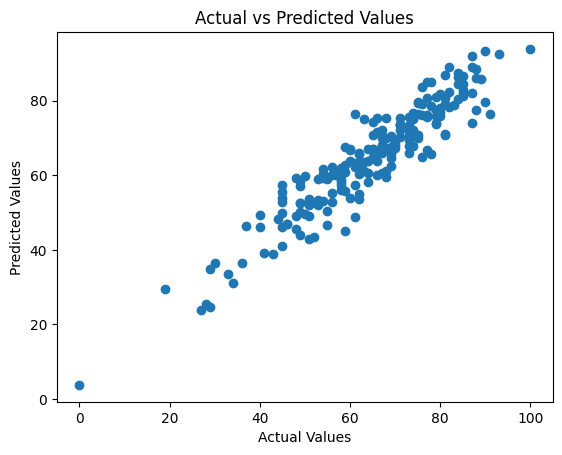

In [25]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

<Axes: xlabel='math_score'>

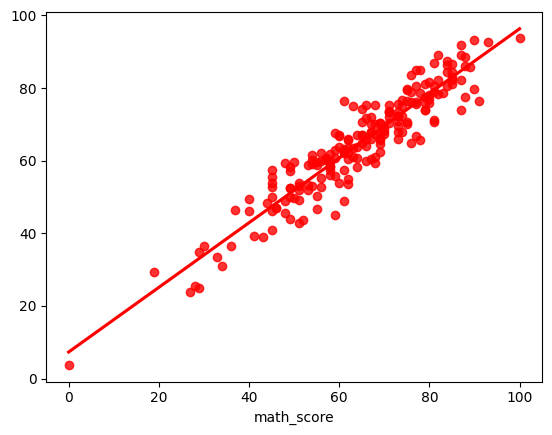

In [26]:
sns.regplot(x=y_test,y=y_pred,ci=None,color="red")

In [27]:
pred_df=pd.DataFrame({"Actual":y_test,"Predicted":y_pred,'Difference':y_test-y_pred})
pred_df

,Actual,Predicted,Difference
521,91,76.507812,14.492188
737,53,58.953125,-5.953125
740,80,76.960938,3.039062
660,74,76.757812,-2.757812
411,84,87.539062,-3.539062
...,...,...,...
408,52,43.546875,8.453125
332,62,62.031250,-0.031250
208,74,67.976562,6.023438
613,65,67.132812,-2.132812
